In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

!pip install numpy pandas matplotlib opencv-python pillow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image

import os
os.makedirs("image_captioning_project", exist_ok=True)
os.chdir("image_captioning_project")

os.makedirs("dataset", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Project folder ready")

[]
Project folder ready


In [ ]:
import urllib.request
import zipfile
import os

os.makedirs("dataset", exist_ok=True)

url = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip"
urllib.request.urlretrieve(url, "dataset/images.zip")

with zipfile.ZipFile("dataset/images.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Images downloaded and extracted")

url = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip"
urllib.request.urlretrieve(url, "dataset/text.zip")

with zipfile.ZipFile("dataset/text.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Captions downloaded and extracted")

print("Number of images:", len(os.listdir("dataset/Flicker8k_Dataset")))

print("Sample images:", os.listdir("dataset/Flicker8k_Dataset")[:5])

Images downloaded and extracted
Captions downloaded and extracted
Number of images: 8091
Sample images: ['3228517564_74b00a923b.jpg', '1332208215_fa824f6659.jpg', '3033686219_452b172ab0.jpg', '207275121_ee4dfa0bf2.jpg', '3182121297_38c99b2769.jpg']


In [ ]:
def load_captions(filename):
    with open(filename, 'r') as file:
        text = file.read()
    return text

captions_text = load_captions("dataset/Flickr8k.token.txt")

def clean_caption(caption):
    caption = caption.lower()
    caption = ''.join([c for c in caption if c.isalpha() or c == ' '])
    caption = 'start ' + caption + ' end'
    return caption

def create_mapping(captions_text):
    mapping = {}

    for line in captions_text.split('\n'):
        if len(line) < 1:
            continue

        tokens = line.split()
        image_id = tokens[0].split('#')[0]
        caption = ' '.join(tokens[1:])

        caption = clean_caption(caption)

        if image_id not in mapping:
            mapping[image_id] = []

        mapping[image_id].append(caption)

    return mapping

mapping = create_mapping(captions_text)

print("Total images:", len(mapping))

for key in list(mapping.keys())[:1]:
    print("Sample captions:", mapping[key])

Total images: 8092
Sample captions: ['start a child in a pink dress is climbing up a set of stairs in an entry way  end', 'start a girl going into a wooden building  end', 'start a little girl climbing into a wooden playhouse  end', 'start a little girl climbing the stairs to her playhouse  end', 'start a little girl in a pink dress going into a wooden cabin  end']


Captions:
- start a child in a pink dress is climbing up a set of stairs in an entry way  end
- start a girl going into a wooden building  end
- start a little girl climbing into a wooden playhouse  end
- start a little girl climbing the stairs to her playhouse  end
- start a little girl in a pink dress going into a wooden cabin  end


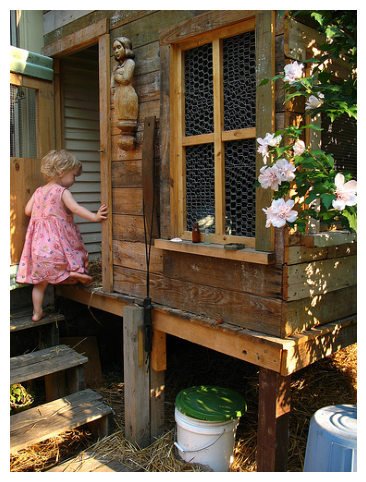

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

image_name = list(mapping.keys())[0]

img = Image.open(f"dataset/Flicker8k_Dataset/{image_name}")

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')

print("Captions:")
for cap in mapping[image_name]:
    print("-", cap)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

all_captions = []
for captions in mapping.values():
    for caption in captions:
        all_captions.append(caption)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)

vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary size:", vocab_size)

def captions_to_sequences(mapping, tokenizer):
    sequences = {}

    for key, captions in mapping.items():
        sequences[key] = []
        for caption in captions:
            seq = tokenizer.texts_to_sequences([caption])[0]
            sequences[key].append(seq)

    return sequences

sequences = captions_to_sequences(mapping, tokenizer)

max_length = max(len(caption.split()) for caption in all_captions)

print("Max caption length:", max_length)

print("\nSample cleaned captions:")
print(mapping[list(mapping.keys())[0]])

print("\nSample sequences:")
print(sequences[list(sequences.keys())[0]])

Vocabulary size: 8779
Max caption length: 37

Sample cleaned captions:
['start a child in a pink dress is climbing up a set of stairs in an entry way  end', 'start a girl going into a wooden building  end', 'start a little girl climbing into a wooden playhouse  end', 'start a little girl climbing the stairs to her playhouse  end', 'start a little girl in a pink dress going into a wooden cabin  end']

Sample sequences:
[[3, 1, 42, 4, 1, 90, 170, 7, 119, 53, 1, 396, 12, 393, 4, 28, 5199, 692, 2], [3, 1, 19, 314, 64, 1, 194, 117, 2], [3, 1, 40, 19, 119, 64, 1, 194, 2423, 2], [3, 1, 40, 19, 119, 5, 393, 20, 60, 2423, 2], [3, 1, 40, 19, 4, 1, 90, 170, 314, 64, 1, 194, 2985, 2]]


In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import os

base_model = VGG16()
feature_extractor = Model(inputs=base_model.inputs, outputs=base_model.layers[-2].output)

print("VGG16 Feature Extractor loaded")


def extract_features(directory):
    features = {}

    for img_name in sorted(os.listdir(directory)):

        if not img_name.endswith('.jpg'):
            continue

        img_path = os.path.join(directory, img_name)

        img = load_img(img_path, target_size=(224, 224))
        img = img_to_array(img)

        img = np.expand_dims(img, axis=0)
        img = preprocess_input(img)

        feature = feature_extractor.predict(img, verbose=0)

        features[img_name] = feature

    return features

#  features = extract_features("dataset/Flicker8k_Dataset")
#  print("Feature extraction completed")

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
VGG16 Feature Extractor loaded


In [ ]:
import pickle
from google.colab import drive
drive.mount('/content/drive')

#  with open("/content/drive/MyDrive/features.pkl", "wb") as f:
#     pickle.dump(features, f)
#  print("Saved to Drive")


with open("/content/drive/MyDrive/features.pkl", "rb") as f:
    features = pickle.load(f)
print("Features loaded")


Mounted at /content/drive
Features loaded


In [ ]:
vocab_size = len(tokenizer.word_index) + 1
print("Vocab size:", vocab_size)
print("Max length:", max_length)

Vocab size: 8779
Max length: 37


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add, Bidirectional

inputs1 = Input(shape=(4096,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.5)(se1)

se3 = Bidirectional(LSTM(128))(se2)

decoder1 = add([fe2, se3])

decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam'
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 4096)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 37, 256)   │  2,247,424 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4096)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 37, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 37)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,048,832 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 256)       │    394,240 │ dropout_1[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8779)      │  2,256,203 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,012,491 (22.94 MB)

 Trainable params: 6,012,491 (22.94 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
def data_generator(mapping, features, tokenizer, max_length, vocab_size, batch_size):
    while True:
        X1, X2, y = [], [], []

        for key, captions in mapping.items():

            if key not in features:
                continue

            feature = features[key][0]

            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]

                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]

                    in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
                    out_seq = to_categorical(out_seq, num_classes=vocab_size)

                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)

                    if len(X1) == batch_size:
                        yield (np.array(X1), np.array(X2)), np.array(y)
                        X1, X2, y = [], [], []

        if len(X1) > 0:
            yield (np.array(X1), np.array(X2)), np.array(y)

In [ ]:
# epochs = 5
# batch_size = 32

# small_mapping = dict(list(mapping.items())[:1000])
# steps = len(small_mapping)
# generator = data_generator(
#     small_mapping,
#     features,
#     tokenizer,
#     max_length,
#     vocab_size,
#     batch_size
# )

# model.fit(
#     generator,
#     epochs=epochs,
#     steps_per_epoch=steps,
#     verbose=1
# )

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5.3234
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 4.6571
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 4.1610
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 3.9413
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 3.7621


In [ ]:
# epochs = 20
# batch_size = 32

# steps = len(mapping)

# generator = data_generator(
#     mapping,
#     features,
#     tokenizer,
#     max_length,
#     vocab_size,
#     batch_size
# )

# model.fit(
#     generator,
#     epochs=epochs,
#     steps_per_epoch=steps,
#     verbose=1
# )

Epoch 1/20
8092/8092 ━━━━━━━━━━━━━━━━━━━━ 114s 14ms/step - loss: 3.9126
Epoch 2/20
8092/8092 ━━━━━━━━━━━━━━━━━━━━ 116s 14ms/step - loss: 3.8113
Epoch 3/20
8092/8092 ━━━━━━━━━━━━━━━━━━━━ 118s 15ms/step - loss: 3.5047
Epoch 4/20
8092/8092 ━━━━━━━━━━━━━━━━━━━━ 115s 14ms/step - loss: 3.4733
Epoch 5/20
8092/8092 ━━━━━━━━━━━━━━━━━━━━ 115s 14ms/step - loss: 3.3434
Epoch 6/20
8092/8092 ━━━━━━━━━━━━━━━━━━━━ 117s 14ms/step - loss: 3.2995
Epoch 7/20
8092/8092 ━━━━━━━━━━━━━━━━━━━━ 114s 14ms/step - loss: 3.2934
Epoch 8/20
8092/8092 ━━━━━━━━━━━━━━━━━━━━ 113s 14ms/step - loss: 3.2245
Epoch 9/20
8092/8092 ━━━━━━━━━━━━━━━━━━━━ 116s 14ms/step - loss: 3.2562
Epoch 10/20
8092/8092 ━━━━━━━━━━━━━━━━━━━━ 116s 14ms/step - loss: 3.1635
Epoch 11/20
8092/8092 ━━━━━━━━━━━━━━━━━━━━ 115s 14ms/step - loss: 3.2252
Epoch 12/20
8092/8092 ━━━━━━━━━━━━━━━━━━━━ 115s 14ms/step - loss: 3.1612
Epoch 13/20
8092/8092 ━━━━━━━━━━━━━━━━━━━━ 116s 14ms/step - loss: 3.1923
Epoch 14/20
8092/8092 ━━━━━━━━━━━━━━━━━━━━ 117s 14ms/step - 

In [ ]:
#  from google.colab import drive
#  drive.mount('/content/drive')

#  model.save('/content/drive/MyDrive/caption_model.keras')
#  print("Model saved successfully")


#  import pickle
#  with open('/content/drive/MyDrive/tokenizer.pkl', 'wb') as f:
#      pickle.dump(tokenizer, f)
#  with open('/content/drive/MyDrive/max_length.pkl', 'wb') as f:
#      pickle.dump(max_length, f)
#  print("Tokenizer & max_length saved")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved successfully
Tokenizer & max_length saved


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/caption_model.keras')
print("Model loaded")


import pickle
with open('/content/drive/MyDrive/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
print("Tokenizer loaded")


with open('/content/drive/MyDrive/max_length.pkl', 'rb') as f:
    max_length = pickle.load(f)
print("Max length loaded")

Model loaded
Tokenizer loaded
Max length loaded


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Image: 3550763985_800cfee7e4.jpg
Generated: a man doing a trick on a skateboard
Matched: start a man doing a trick on skateboard end


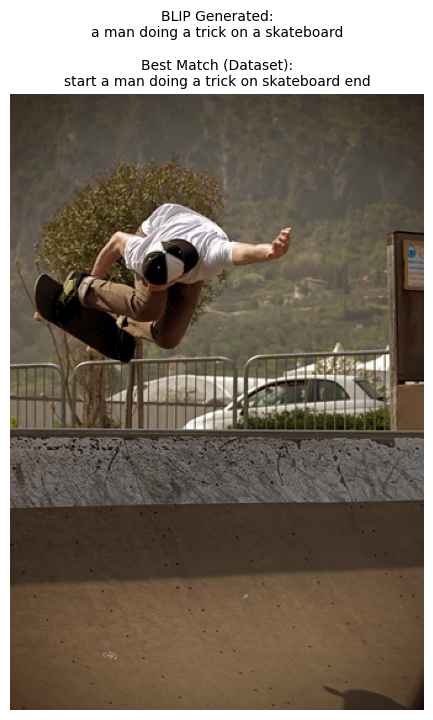

In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import torch
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model_blip = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

all_captions = []
for caps in mapping.values():
    all_captions.extend(caps)

def generate_and_match_caption(image_path):

    img = Image.open(image_path).convert("RGB")
    inputs = processor(img, return_tensors="pt")

    out = model_blip.generate(**inputs)
    generated_caption = processor.decode(out[0], skip_special_tokens=True)

    texts = [generated_caption] + all_captions

    vectorizer = TfidfVectorizer()
    vectors = vectorizer.fit_transform(texts)

    similarity = cosine_similarity(vectors[0:1], vectors[1:])
    best_idx = similarity.argmax()

    matched_caption = all_captions[best_idx]

    return generated_caption, matched_caption


import random

image_name = random.choice(os.listdir("dataset/Flicker8k_Dataset"))
image_path = f"dataset/Flicker8k_Dataset/{image_name}"

gen_caption, match_caption = generate_and_match_caption(image_path)

img = Image.open(image_path)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis('off')

plt.title(
    f"BLIP Generated:\n{gen_caption}\n\nBest Match (Dataset):\n{match_caption}",
    fontsize=10
)

print("Image:", image_name)
print("Generated:", gen_caption)
print("Matched:", match_caption)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import random

test_images = random.sample(list(mapping.keys()), 50)

y_true = []
y_pred = []

for img_name in test_images:

    image_path = f"dataset/Flicker8k_Dataset/{img_name}"

    gen_caption, _ = generate_and_match_caption(image_path)

    gen_words = set(gen_caption.lower().split())

    real_captions = [
        c.replace("start", "").replace("end", "").strip().lower()
        for c in mapping[img_name]
    ]

    best_match_score = 0

    for real in real_captions:

        real_words = set(real.split())

        common_words = gen_words.intersection(real_words)

        score = len(common_words) / max(len(real_words), 1)

        best_match_score = max(best_match_score, score)

    y_true.append(1)

    if best_match_score >= 0.35:
        y_pred.append(1)
    else:
        y_pred.append(0)


accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\n===== MODEL EVALUATION =====\n")

print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1 Score  : {f1:.2f}")

print("\n===== CONFUSION MATRIX =====\n")
print(confusion_matrix(y_true, y_pred))

print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(y_true, y_pred))


===== MODEL EVALUATION =====

Accuracy  : 74.00%
Precision : 1.00
Recall    : 0.74
F1 Score  : 0.85

===== CONFUSION MATRIX =====

[[ 0  0]
 [13 37]]

===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.74      0.85        50

    accuracy                           0.74        50
   macro avg       0.50      0.37      0.43        50
weighted avg       1.00      0.74      0.85        50



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pickle

with open("/content/mapping.pkl", "wb") as f:
    pickle.dump(mapping, f)

print("Saved Successfully")

Saved Successfully
